### This project demonstrates an end-to-end data integration and analysis workflow using a real-world Kaggle dataset that examines the relationship between gaming habits and academic or work performance. The dataset was cleaned and processed using Python, then transferred to a SQL Server database through a pyodbc connection. All records were stored in a relational table, and statistical analysis was performed using SQL aggregate functions such as mean, median, and mode. The project highlights how Python can be used for data ingestion and database connectivity, while SQL is utilized for efficient data aggregation and insight generation.

In [ ]:
!pip install kagglehub


   ---------------------------------------- 0/2 [pyyaml]
   ---------------------------------------- 0/2 [pyyaml]
   ---------------------------------------- 0/2 [pyyaml]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   -------------------- ------------------- 1/2 [kagglehub]
   ---------------------------------------- 2/2 [kagglehub]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## IMPORTING DATA 

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prince7489/gaming-hours-vs-academic-and-work-performance")

print("Path to dataset files:", path)

d:\NOUSHAD ALAM\ALL SOFTWARE FILE\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 15.0k/15.0k [00:00<00:00, 6.54MB/s]

Extracting files...
Path to dataset files: C:\Users\ADVANCES--PC\.cache\kagglehub\datasets\prince7489\gaming-hours-vs-academic-and-work-performance\versions\1


## PROCESSING DATA 

### Python Code to Inspect

In [8]:
import pandas as pd

df = pd.read_csv("Gaming_Hours_vs_Performance_1000_Rows.csv")
print(df.shape)
print(df.head())
print(df.info())


(1000, 14)
  User_ID  Age  Gender            Occupation Game_Type  Daily_Gaming_Hours  \
0   U0001   21    Male  Working Professional    Action                 4.0   
1   U0002   35  Female               Student    Sports                 1.0   
2   U0003   26    Male               Student    Puzzle                 2.0   
3   U0004   32    Male  Working Professional    Action                 1.0   
4   U0005   19    Male  Working Professional    Action                 2.1   

   Weekly_Gaming_Hours Primary_Gaming_Time  Sleep_Hours  Stress_Level  \
0                 28.0             Morning          4.6             6   
1                  7.0               Night          5.4             2   
2                 14.0             Morning          8.0             4   
3                  7.0               Night          4.9             7   
4                 14.7             Morning          7.0             7   

   Focus_Level  Academic_or_Work_Score  Productivity_Level Performance_Impact  
0

In [9]:
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (1000, 14)


In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)
    print(f"After imputing missing values in {col}:", df[col].isnull().sum())

After imputing missing values in Age: 0
After imputing missing values in Daily_Gaming_Hours: 0
After imputing missing values in Weekly_Gaming_Hours: 0
After imputing missing values in Sleep_Hours: 0
After imputing missing values in Stress_Level: 0
After imputing missing values in Focus_Level: 0
After imputing missing values in Academic_or_Work_Score: 0
After imputing missing values in Productivity_Level: 0


C:\Users\ADVANCES--PC\AppData\Local\Temp\ipykernel_13908\741480733.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\ADVANCES--PC\AppData\Local\Temp\ipykernel_13908\953848526.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")


In [13]:
print("Final cleaned data info:")
print(df.info())

Final cleaned data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 1000 non-null   object 
 1   age                     1000 non-null   int64  
 2   gender                  1000 non-null   object 
 3   occupation              1000 non-null   object 
 4   game_type               1000 non-null   object 
 5   daily_gaming_hours      1000 non-null   float64
 6   weekly_gaming_hours     1000 non-null   float64
 7   primary_gaming_time     1000 non-null   object 
 8   sleep_hours             1000 non-null   float64
 9   stress_level            1000 non-null   int64  
 10  focus_level             1000 non-null   int64  
 11  academic_or_work_score  1000 non-null   int64  
 12  productivity_level      1000 non-null   int64  
 13  performance_impact      1000 non-null   object 
dtypes: float64(3), i

In [15]:
df = df[df["daily_gaming_hours"] >= 0]
print("After removing invalid gaming hours:", df.shape)

After removing invalid gaming hours: (1000, 14)


In [16]:
df = df[df["weekly_gaming_hours"] >= 0]
print("After removing invalid gaming hours:", df.shape)

After removing invalid gaming hours: (1000, 14)


In [19]:
df.info()
df.isnull().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 1000 non-null   object 
 1   age                     1000 non-null   int64  
 2   gender                  1000 non-null   object 
 3   occupation              1000 non-null   object 
 4   game_type               1000 non-null   object 
 5   daily_gaming_hours      1000 non-null   float64
 6   weekly_gaming_hours     1000 non-null   float64
 7   primary_gaming_time     1000 non-null   object 
 8   sleep_hours             1000 non-null   float64
 9   stress_level            1000 non-null   int64  
 10  focus_level             1000 non-null   int64  
 11  academic_or_work_score  1000 non-null   int64  
 12  productivity_level      1000 non-null   int64  
 13  performance_impact      1000 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory

user_id                   0
age                       0
gender                    0
occupation                0
game_type                 0
daily_gaming_hours        0
weekly_gaming_hours       0
primary_gaming_time       0
sleep_hours               0
stress_level              0
focus_level               0
academic_or_work_score    0
productivity_level        0
performance_impact        0
dtype: int64

In [20]:
df.to_csv("gaming_cleaned.csv", index=False)


In [22]:
df.head(100)

,user_id,age,gender,occupation,game_type,daily_gaming_hours,weekly_gaming_hours,primary_gaming_time,sleep_hours,stress_level,focus_level,academic_or_work_score,productivity_level,performance_impact
0,U0001,21,Male,Working Professional,Action,4.0,28.0,Morning,4.6,6,4,69,66,Negative
1,U0002,35,Female,Student,Sports,1.0,7.0,Night,5.4,2,7,67,72,Neutral
2,U0003,26,Male,Student,Puzzle,2.0,14.0,Morning,8.0,4,8,82,82,Positive
3,U0004,32,Male,Working Professional,Action,1.0,7.0,Night,4.9,7,7,71,66,Neutral
4,U0005,19,Male,Working Professional,Action,2.1,14.7,Morning,7.0,7,7,67,63,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,U0096,30,Female,Student,Strategy,4.0,28.0,Evening,6.2,6,6,74,72,Neutral
96,U0097,18,Male,Working Professional,Puzzle,3.6,25.2,Morning,6.8,6,3,80,79,Neutral
97,U0098,22,Male,Student,Puzzle,3.8,26.6,Evening,5.9,5,7,71,76,Neutral
98,U0099,31,Male,Student,Strategy,0.7,4.9,Night,6.0,4,3,73,73,Neutral


## Load Cleaned Dataset

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("gaming_cleaned.csv")


## DATA ANALYSIS (5 Analyses)

### ANALYSIS 1: Average Score by Gaming Hours Group

In [39]:
df["gaming_group"] = pd.cut(
    df["daily_gaming_hours"],
    bins=[0, 2, 4, 10],
    labels=["Low", "Moderate", "High"]
)

avg_score_by_gaming = df.groupby("gaming_group")["academic_or_work_score"].mean().reset_index()


C:\Users\ADVANCES--PC\AppData\Local\Temp\ipykernel_13908\2123019628.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_score_by_gaming = df.groupby("gaming_group")["academic_or_work_score"].mean().reset_index()


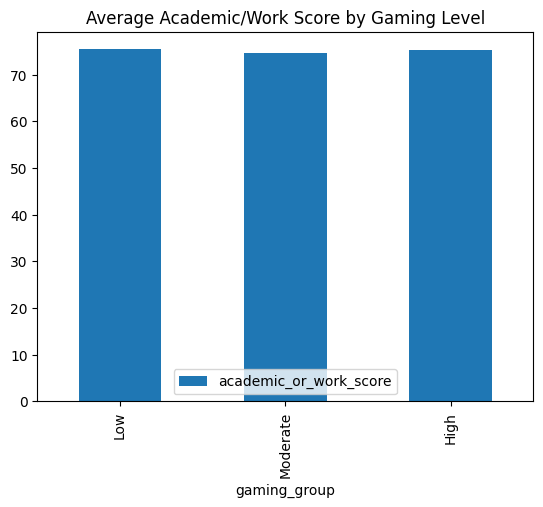

In [40]:
avg_score_by_gaming.plot(
    x="gaming_group",
    y="academic_or_work_score",
    kind="bar",
    title="Average Academic/Work Score by Gaming Level"
)
plt.show()


### ANALYSIS 2: Productivity Level by Gender & Occupation

C:\Users\ADVANCES--PC\AppData\Local\Temp\ipykernel_13908\4098759581.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_vs_gaming = df.groupby("gaming_group")["stress_level"].mean().reset_index()


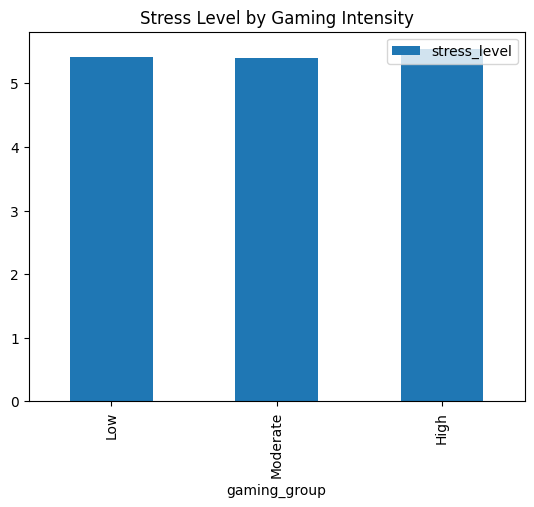

In [41]:
stress_vs_gaming = df.groupby("gaming_group")["stress_level"].mean().reset_index()

stress_vs_gaming.plot(
    x="gaming_group",
    y="stress_level",
    kind="bar",
    title="Stress Level by Gaming Intensity"
)
plt.show()


### ANALYSIS 3: Productivity by Game Type

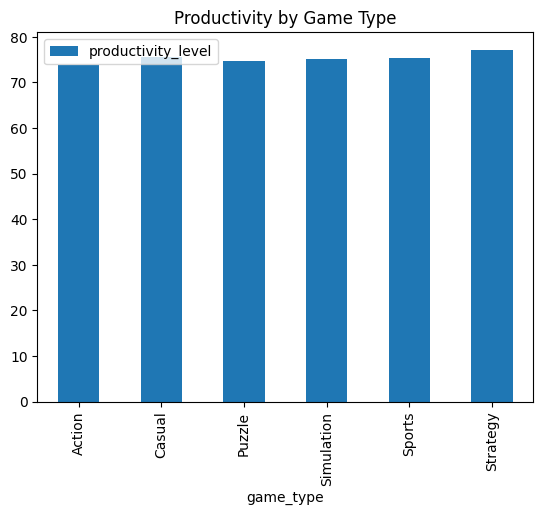

In [42]:
productivity_by_game = df.groupby("game_type")["productivity_level"].mean().reset_index()

productivity_by_game.plot(
    x="game_type",
    y="productivity_level",
    kind="bar",
    title="Productivity by Game Type"
)
plt.show()


### ANALYSIS 4: Sleep Hours vs Performance Impact

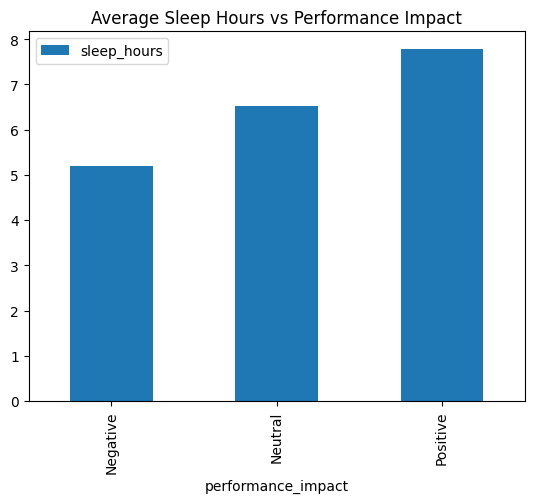

In [43]:
sleep_performance = df.groupby("performance_impact")["sleep_hours"].mean().reset_index()

sleep_performance.plot(
    x="performance_impact",
    y="sleep_hours",
    kind="bar",
    title="Average Sleep Hours vs Performance Impact"
)
plt.show()


### ANALYSIS 5: Focus Level by Primary Gaming Time

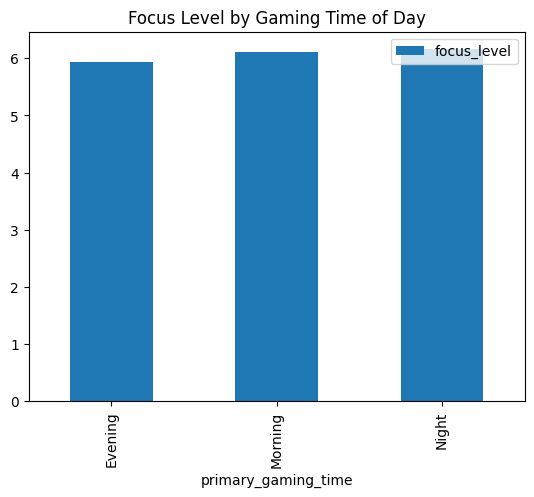

In [44]:
focus_by_time = df.groupby("primary_gaming_time")["focus_level"].mean().reset_index()

focus_by_time.plot(
    x="primary_gaming_time",
    y="focus_level",
    kind="bar",
    title="Focus Level by Gaming Time of Day"
)
plt.show()


## PART 2: PREPARE ANALYSIS TABLES FOR SQL

In [45]:
analysis_tables = {
    "avg_score_by_gaming": avg_score_by_gaming,
    "stress_vs_gaming": stress_vs_gaming,
    "productivity_by_game": productivity_by_game,
    "sleep_performance": sleep_performance,
    "focus_by_time": focus_by_time
}


### PART 3: UPLOAD ANALYSIS DATA TO SQL SERVER (pyodbc)

In [1]:
import pyodbc
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("gaming_cleaned.csv")

# SQL Server connection
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=NOUSHAD-ALAM;"
    "DATABASE=GamingProject;"
    "Trusted_Connection=yes;"
)

cursor = conn.cursor()


In [2]:
cursor.execute("DROP TABLE IF EXISTS gaming_performance")
conn.commit()


In [3]:
cursor.execute("""
CREATE TABLE gaming_performance (
    user_id VARCHAR(10),
    age INT,
    gender VARCHAR(10),
    occupation VARCHAR(30),
    game_type VARCHAR(20),
    daily_gaming_hours FLOAT,
    weekly_gaming_hours FLOAT,
    primary_gaming_time VARCHAR(20),
    sleep_hours FLOAT,
    stress_level INT,
    focus_level INT,
    academic_or_work_score INT,
    productivity_level INT,
    performance_impact VARCHAR(10)
)
""")
conn.commit()


In [4]:
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO gaming_performance VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)
    """,
    row.user_id,
    int(row.age),
    row.gender,
    row.occupation,
    row.game_type,
    float(row.daily_gaming_hours),
    float(row.weekly_gaming_hours),
    row.primary_gaming_time,
    float(row.sleep_hours),
    int(row.stress_level),
    int(row.focus_level),
    int(row.academic_or_work_score),
    int(row.productivity_level),
    row.performance_impact
    )

conn.commit()
print("✅ Full dataset uploaded to SQL Server")


✅ Full dataset uploaded to SQL Server
